# 00_a_sbatch_orchestrator_and_output_monitor

This notebook has two sections first orchestrate embeddgins and cosines 

1)run and monitor

set is: for 14 months vs 1000 random jobs per month.
models bge e5 gte

first ochestrates and monitors execution of embeddings
than do the same for cosines, for all 3 models

orchestration is important cause we running several different models.

2) verification of outputs

after successful run section 2 provides data analysis and
check agreements and disgragrements  betweeen models


*helper functions*

this notebook relies on that are in `helpers_00_a_sbatch_orchestrator.py` NOT WORKING

3) creating cosine dataset for each model for next stage.

be careful, if you create another randonm sample in `00_create_sample_onet_and_target_dataset_for_embedding`  you have to re run everythign!
    
    

# 1) run and monitor

In [1]:
#Imports + config
import subprocess
import time
import re
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime
from IPython.display import display, HTML, clear_output
import json

# Helpers
def submit_job(sbatch_file, dry_run=False):
    """Submit sbatch job and return job ID"""
    cmd = ["sbatch", str(sbatch_file)]
    
    if dry_run:
        print(f"[DRY RUN] Would submit: {sbatch_file.name}")
        return f"DRY_{sbatch_file.stem}"
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True,    check=True, cwd=PROJECT_ROOT)
        # Parse: "Submitted batch job 1234567"
        match = re.search(r'Submitted batch job (\d+)', result.stdout)
        if match:
            job_id = match.group(1)
            print(f"✓ Submitted {sbatch_file.name} → Job ID: {job_id}")
            return job_id
        else:
            print(f"✗ Failed to parse job ID from: {result.stdout}")
            return None
    except subprocess.CalledProcessError as e:
        print(f"✗ Error submitting {sbatch_file.name}:")
        print(f"  stderr: {e.stderr}")
        return None


def get_job_status(job_id):
    """Get status of a job or array job"""
    if job_id.startswith("DRY_"):
        return "DRY_RUN"
    
    cmd = ["squeue", "-j", str(job_id), "-h", "-o", "%T"]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0 or not result.stdout.strip():
            # Job not in queue, check sacct
            cmd_sacct = ["sacct", "-j", str(job_id), "-n", "-o", "State", "-P"]
            result = subprocess.run(cmd_sacct, capture_output=True, text=True)
            if result.stdout.strip():
                states = result.stdout.strip().split('\n')
                # Return most recent state
                return states[0]
            return "UNKNOWN"
        
        statuses = result.stdout.strip().split('\n')
        # For array jobs, could have multiple states
        if len(statuses) > 1:
            # Count states
            from collections import Counter
            state_counts = Counter(statuses)
            return f"{dict(state_counts)}"
        return statuses[0]
    except Exception as e:
        return f"ERROR: {e}"


def wait_for_job(job_id, poll_interval=30, max_wait=7200):
    """Wait for a single job to complete"""
    if job_id.startswith("DRY_"):
        print(f"  [DRY RUN] Skipping wait for {job_id}")
        return "DRY_RUN"
    
    start = time.time()
    while time.time() - start < max_wait:
        status = get_job_status(job_id)
        
        if isinstance(status, str) and status in ["COMPLETED", "FAILED", "CANCELLED", "TIMEOUT"]:
            return status
        
        # For array jobs with dict status
        if isinstance(status, str) and status.startswith("{"):
            # Parse dict string
            try:
                status_dict = eval(status)
                if all(s in ["COMPLETED", "FAILED", "CANCELLED"] for s in status_dict.keys()):
                    return status_dict
            except:
                pass
        
        time.sleep(poll_interval)
    
    return "TIMEOUT"


def wait_for_jobs(job_dict, poll_interval=30):
    """Wait for multiple jobs with live status display"""
    if all(jid.startswith("DRY_") for jid in job_dict.values()):
        print("[DRY RUN] All jobs are dry run, skipping wait")
        return {k: "DRY_RUN" for k in job_dict}
    
    results = {}
    print(f"\n{'Model':<10} {'Job ID':<12} {'Status':<30} {'Elapsed':<10}")
    print("-" * 65)
    
    start_time = time.time()
    while len(results) < len(job_dict):
        for model, job_id in job_dict.items():
            if model in results:
                continue
            
            status = get_job_status(job_id)
            elapsed = time.time() - start_time
            elapsed_str = f"{elapsed/60:.1f}m"
            
            # Truncate long status strings
            status_str = str(status)[:28]
            print(f"{model:<10} {job_id:<12} {status_str:<30} {elapsed_str:<10}")
            
            # Check completion
            if isinstance(status, str) and status in ["COMPLETED", "FAILED", "CANCELLED", "TIMEOUT", "UNKNOWN"]:
                results[model] = status
            elif isinstance(status, str) and status.startswith("{"):
                # Array job with all tasks done
                try:
                    status_dict = eval(status)
                    if all(s in ["COMPLETED", "FAILED", "CANCELLED"] for s in status_dict.keys()):
                        results[model] = status
                except:
                    pass
        
        if len(results) < len(job_dict):
            time.sleep(poll_interval)
            clear_output(wait=True)
            print(f"\n{'Model':<10} {'Job ID':<12} {'Status':<30} {'Elapsed':<10}")
            print("-" * 65)
    
    print(f"\n✓ All jobs completed in {(time.time()-start_time)/60:.1f} minutes")
    return results


def verify_file(filepath, min_size_mb=0.1):
    """Check if file exists and meets size requirement"""
    p = Path(filepath)
    if not p.exists():
        return False, "MISSING"
    
    size_mb = p.stat().st_size / (1024 * 1024)
    if size_mb < min_size_mb:
        return False, f"TOO_SMALL ({size_mb:.2f}MB)"
    
    return True, f"OK ({size_mb:.1f}MB)"



# ============================================================
# HELPERS
# ============================================================
def load_titles(npz_path: Path):
    if not npz_path.exists():
        return None
    d = np.load(npz_path, allow_pickle=True)
    return d["titles"] if "titles" in d.files else None

def pretty_candidates(indices, titles=None):
    if titles is None:
        return [int(i) for i in indices]
    return [str(titles[int(i)]) if 0 <= int(i) < len(titles) else f"<bad_idx:{int(i)}>" for i in indices]

def coerce_job_ids(x):
    try:
        return x.astype(np.int64)
    except Exception:
        return np.array([str(v) for v in x], dtype=object)

def assert_topk(arr, name):
    if arr.ndim != 2:
        raise ValueError(f"{name} expected 2D [n,k], got {arr.shape}")
    if arr.shape[1] != TOPK_EXPECTED:
        raise ValueError(f"{name} expected TOPK={TOPK_EXPECTED}, got k={arr.shape[1]}")

def load_all_parts(root: Path):
    parts = sorted(root.rglob("part_*.npz"))
    if not parts:
        raise FileNotFoundError(f"No part_*.npz under {root}")

    job_ids, rix, rval, tix, tval = [], [], [], [], []
    for p in parts:
        d = np.load(p, allow_pickle=True)
        need = {"job_ids", "role_topk_idx", "role_topk_val", "task_topk_idx", "task_topk_val"}
        miss = need - set(d.files)
        if miss:
            raise KeyError(f"{p} missing keys: {sorted(miss)}")
        job_ids.append(d["job_ids"])
        rix.append(d["role_topk_idx"]); rval.append(d["role_topk_val"])
        tix.append(d["task_topk_idx"]); tval.append(d["task_topk_val"])

    out = {
        "job_ids": np.concatenate(job_ids),
        "role_idx": np.vstack(rix),
        "role_val": np.vstack(rval),
        "task_idx": np.vstack(tix),
        "task_val": np.vstack(tval),
    }
    assert_topk(out["role_idx"], f"{root.name}.role_idx")
    assert_topk(out["task_idx"], f"{root.name}.task_idx")
    return out

def align_k(models, names):
    sets = []
    maps = {}
    for n in names:
        ids = coerce_job_ids(models[n]["job_ids"])
        maps[n] = {jid: i for i, jid in enumerate(ids)}
        sets.append(set(maps[n].keys()))
    common = sorted(set.intersection(*sets))
    if not common:
        raise RuntimeError(f"No overlapping job_ids across {names}")
    idx = {n: np.array([maps[n][j] for j in common], dtype=np.int32) for n in names}
    return common, idx

def jaccard_topk(a_idx, b_idx):
    n = a_idx.shape[0]
    out = np.empty(n, dtype=np.float32)
    for i in range(n):
        A = set(map(int, a_idx[i]))
        B = set(map(int, b_idx[i]))
        out[i] = len(A & B) / len(A | B) if (A | B) else 1.0
    return out

def summary(x, name):
    x = np.asarray(x)
    print(f"{name}: mean={x.mean():.3f} p50={np.median(x):.3f} p10={np.quantile(x,0.10):.3f} p90={np.quantile(x,0.90):.3f} min={x.min():.3f} max={x.max():.3f}")

def plot_hist(x, title):
    plt.figure()
    plt.hist(x, bins=np.linspace(0, 1, 11))
    plt.title(title)
    plt.xlabel("Jaccard")
    plt.ylabel("count")
    plt.grid(True)
    plt.show()

def show_examples(nameA, nameB, job_ids, A, B, *, titles=None):
    jac = jaccard_topk(A, B)
    hi = int(np.argmax(jac)); lo = int(np.argmin(jac))

    def dump(i, tag):
        print("\n==============================")
        print(f"{nameA} vs {nameB} | {tag} | job_id={job_ids[i]}")
        print("ROLE A:", pretty_candidates(A[i], titles))
        print("ROLE B:", pretty_candidates(B[i], titles))

    dump(hi, "HIGH overlap")
    dump(lo, "LOW overlap")

def margin_stats(vals, name):
    top1 = vals[:, 0]; top2 = vals[:, 1]
    m = top1 - top2
    print(f"{name} top1: mean={top1.mean():.3f} p50={np.median(top1):.3f} p10={np.quantile(top1,0.10):.3f} p90={np.quantile(top1,0.90):.3f}")
    print(f"{name} margin: mean={m.mean():.3f} p50={np.median(m):.3f} p10={np.quantile(m,0.10):.3f} p90={np.quantile(m,0.90):.3f}")


def top1_metrics(a_idx, b_idx, name):
    a_top1 = a_idx[:, 0]
    b_top1 = b_idx[:, 0]

    exact = np.mean(a_top1 == b_top1)

    a_in_b5 = np.mean([
        a_top1[i] in set(b_idx[i]) for i in range(len(a_top1))
    ])
    b_in_a5 = np.mean([
        b_top1[i] in set(a_idx[i]) for i in range(len(b_top1))
    ])

    print(f"{name}")
    print(f"  top1 == top1:      {exact:.3f}")
    print(f"  A top1 in B top5:  {a_in_b5:.3f}")
    print(f"  B top1 in A top5:  {b_in_a5:.3f}")

print("✓ Helper functions loaded")



✓ Helper functions loaded


In [2]:
# Configuration
PROJECT_ROOT = Path("/projects/a5u/adu_dev/aisi-economy-index")
SBATCH_DIR = PROJECT_ROOT / "nbs/AISI_demo/Stage_2_Embeddings_and_Cosine_sim/dev/sbatch"
EMBEDDINGS_ROOT = PROJECT_ROOT / "aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/embeddings"
COSINES_ROOT = PROJECT_ROOT / "aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines"

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Sbatch dir: {SBATCH_DIR}")
print(f"✓ Embeddings: {EMBEDDINGS_ROOT}")
print(f"✓ Cosines: {COSINES_ROOT}")

✓ Project root: /projects/a5u/adu_dev/aisi-economy-index
✓ Sbatch dir: /projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_2_Embeddings_and_Cosine_sim/dev/sbatch
✓ Embeddings: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/embeddings
✓ Cosines: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines


In [3]:
# Define ONET embedding jobs
onet_jobs_config = {
    "bge": {
        "sbatch": SBATCH_DIR / "embed_onet_large_bge.sbatch",
        "outputs": [
            EMBEDDINGS_ROOT / "run_embed_onet_bge/embeddings_role_onet_bge_large.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_bge/embeddings_tasks_onet_bge_large.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_bge/onet_row_idx_bge.npy"
        ]
    },
    "e5": {
        "sbatch": SBATCH_DIR / "embed_onet_large_e5.sbatch",
        "outputs": [
            EMBEDDINGS_ROOT / "run_embed_onet_e5/embeddings_role_onet_e5_large_v2.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_e5/embeddings_tasks_onet_e5_large_v2.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_e5/onet_row_idx_e5_large_v2.npy"
        ]
    },
    "gte": {
        "sbatch": SBATCH_DIR / "embed_onet_large_gte.sbatch",
        "outputs": [
            EMBEDDINGS_ROOT / "run_embed_onet_gte/embeddings_role_onet_gte_large_en_v1p5.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_gte/embeddings_tasks_onet_gte_large_en_v1p5.npy",
            EMBEDDINGS_ROOT / "run_embed_onet_gte/onet_row_idx_gte_large_en_v1p5.npy"
        ]
    }
}


print("Phase 1: ONET Embedding Jobs")
for model, config in onet_jobs_config.items():
    print(f"  {model}: {config['sbatch'].name}")
    print(f"    → {len(config['outputs'])} output files expected")

Phase 1: ONET Embedding Jobs
  bge: embed_onet_large_bge.sbatch
    → 3 output files expected
  e5: embed_onet_large_e5.sbatch
    → 3 output files expected
  gte: embed_onet_large_gte.sbatch
    → 3 output files expected


In [4]:
def submit_job(sbatch_file, dry_run=False):
    """Submit sbatch job and return job ID"""
    cmd = ["sbatch", str(sbatch_file)]
    
    if dry_run:
        print(f"[DRY RUN] Would submit: {sbatch_file.name}")
        return f"DRY_{sbatch_file.stem}"
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True, cwd=PROJECT_ROOT)
        # Parse: "Submitted batch job 1234567"
        match = re.search(r'Submitted batch job (\d+)', result.stdout)
        if match:
            job_id = match.group(1)
            print(f"✓ Submitted {sbatch_file.name} → Job ID: {job_id}")
            return job_id
        else:
            print(f"✗ Failed to parse job ID from: {result.stdout}")
            return None
    except subprocess.CalledProcessError as e:
        print(f"✗ Error submitting {sbatch_file.name}:")
        print(f"  stderr: {e.stderr}")
        return None

In [5]:
## __Phase 1 - Submit ONET Jobs__


DRY_RUN = False  # Set to True to test without submitting

print("="*70)
print("PHASE 1: ONET EMBEDDINGS")
print("="*70)

onet_job_ids = {}
for model, config in onet_jobs_config.items():
    sbatch_file = config["sbatch"]
    job_id = submit_job(sbatch_file, dry_run=DRY_RUN)
    if job_id:
        onet_job_ids[model] = job_id

print(f"\n✓ Submitted {len(onet_job_ids)} ONET embedding jobs")


PHASE 1: ONET EMBEDDINGS
✓ Submitted embed_onet_large_bge.sbatch → Job ID: 2151364
✓ Submitted embed_onet_large_e5.sbatch → Job ID: 2151365
✓ Submitted embed_onet_large_gte.sbatch → Job ID: 2151366

✓ Submitted 3 ONET embedding jobs


In [6]:
## __Phase 1 - Monitor ONET Jobs__


print("\nMonitoring ONET embedding jobs...")
onet_results = wait_for_jobs(onet_job_ids, poll_interval=30)

print("\n" + "="*70)
print("PHASE 1 RESULTS:")
for model, status in onet_results.items():
    symbol = "✓" if "COMPLETED" in str(status) else "✗"
    print(f"{symbol} {model}: {status}")




Model      Job ID       Status                         Elapsed   
-----------------------------------------------------------------
bge        2151364      COMPLETED                      0.5m      
e5         2151365      COMPLETED                      0.5m      
gte        2151366      COMPLETED                      0.5m      

✓ All jobs completed in 0.5 minutes

PHASE 1 RESULTS:
✓ bge: COMPLETED
✓ e5: COMPLETED
✓ gte: COMPLETED


In [7]:
## __Phase 1 - Verify ONET Outputs__

print("\n" + "="*70)
print("PHASE 1 OUTPUT VERIFICATION")
print("="*70)

onet_verification = {}
all_good = True



for model, config in onet_jobs_config.items():
    print(f"\n{model.upper()}:")
    model_files = []
    
    for filepath in config["outputs"]:
        exists, status = verify_file(filepath)#, min_size_mb=0.005)
        symbol = "✓" if exists else "✗"
        print(f"  {symbol} {filepath.name}: {status}")
        model_files.append(exists)
        
        if not exists:
            all_good = False
    
    onet_verification[model] = all(model_files)

if all_good:
    print("\n✓ All ONET embedding files verified!")
else:
    print("\n✗ Some ONET embedding files are missing or too small")
    print("   Check logs before proceeding to Phase 2")



PHASE 1 OUTPUT VERIFICATION

BGE:
  ✓ embeddings_role_onet_bge_large.npy: OK (1.7MB)
  ✓ embeddings_tasks_onet_bge_large.npy: OK (1.7MB)
  ✗ onet_row_idx_bge.npy: TOO_SMALL (0.01MB)

E5:
  ✓ embeddings_role_onet_e5_large_v2.npy: OK (1.7MB)
  ✓ embeddings_tasks_onet_e5_large_v2.npy: OK (1.7MB)
  ✗ onet_row_idx_e5_large_v2.npy: TOO_SMALL (0.00MB)

GTE:
  ✓ embeddings_role_onet_gte_large_en_v1p5.npy: OK (1.7MB)
  ✓ embeddings_tasks_onet_gte_large_en_v1p5.npy: OK (1.7MB)
  ✗ onet_row_idx_gte_large_en_v1p5.npy: TOO_SMALL (0.00MB)

✗ Some ONET embedding files are missing or too small
   Check logs before proceeding to Phase 2


In [8]:
## __Phase 2 Configuration - Target Embeddings__


# Define Target embedding jobs (array jobs: 0-27 = 14 months × 2 shards)
target_jobs_config = {
    "bge": {
        "sbatch": SBATCH_DIR / "embed_target_large_bge.sbatch",
        "output_dir": EMBEDDINGS_ROOT / "run_embed_target/bge_large",
        "n_tasks": 28
    },
    "e5": {
        "sbatch": SBATCH_DIR / "embed_target_large_e5.sbatch",
        "output_dir": EMBEDDINGS_ROOT / "run_embed_target/e5_large",
        "n_tasks": 28
    },
    "gte": {
        "sbatch": SBATCH_DIR / "embed_target_large_gte.sbatch",
        "output_dir": EMBEDDINGS_ROOT / "run_embed_target/gte_large",
        "n_tasks": 28
    }
}

print("Phase 2: Target Embedding Jobs")
for model, config in target_jobs_config.items():
    print(f"  {model}: {config['sbatch'].name}")
    print(f"    → Array job with {config['n_tasks']} tasks")


Phase 2: Target Embedding Jobs
  bge: embed_target_large_bge.sbatch
    → Array job with 28 tasks
  e5: embed_target_large_e5.sbatch
    → Array job with 28 tasks
  gte: embed_target_large_gte.sbatch
    → Array job with 28 tasks


In [22]:
## Phase 2 - Submit Target Jobs__

all_good = True
print("="*70)
print("PHASE 2: TARGET EMBEDDINGS")
print("="*70)

if not all_good:
    print("✗ STOPPING: Phase 1 verification failed")
    print("  Fix ONET embeddings before proceeding")
else:
    target_job_ids = {}
    for model, config in target_jobs_config.items():
        sbatch_file = config["sbatch"]
        job_id = submit_job(sbatch_file, dry_run=DRY_RUN)
        if job_id:
            target_job_ids[model] = job_id
    
    print(f"\n✓ Submitted {len(target_job_ids)} Target embedding array jobs")


PHASE 2: TARGET EMBEDDINGS
✓ Submitted embed_target_large_bge.sbatch → Job ID: 2151463
✓ Submitted embed_target_large_e5.sbatch → Job ID: 2151464
✓ Submitted embed_target_large_gte.sbatch → Job ID: 2151465

✓ Submitted 3 Target embedding array jobs


In [23]:
## __Phase 2 - Monitor Target Jobs__

if all_good and target_job_ids:

    print("\nMonitoring Target embedding jobs (this may take a while)...")
    target_results = wait_for_jobs(target_job_ids, poll_interval=60)
    
    print("\n" + "="*70)
    print("PHASE 2 RESULTS:")
    for model, status in target_results.items():
        print(f"  {model}: {status}")




Monitoring Target embedding jobs (this may take a while)...

Model      Job ID       Status                         Elapsed   
-----------------------------------------------------------------
bge        2151463      COMPLETED                      0.0m      
e5         2151464      COMPLETED                      0.0m      
gte        2151465      COMPLETED                      0.0m      

✓ All jobs completed in 0.0 minutes

PHASE 2 RESULTS:
  bge: COMPLETED
  e5: COMPLETED
  gte: COMPLETED


In [24]:
## __Phase 2 - Verify Target Outputs__

print("\n" + "="*70)
print("PHASE 2 OUTPUT VERIFICATION")
print("="*70)

target_verification = {}
all_targets_good = True

for model, config in target_jobs_config.items():
    out_dir = config["output_dir"]
    print(f"\n{model.upper()}:")
    
    # Expected: 14 months × 2 shards = 28 files
    # Pattern: adzuna_month{01-14}_shard{00-01}_of02.npz
    expected_count = 28
    actual_files = list(out_dir.rglob("*.npz")) if out_dir.exists() else []
    
    print(f"  Expected files: {expected_count}")
    print(f"  Found files: {len(actual_files)}")
    
    if len(actual_files) == expected_count:
        # Sample check a few
        for f in actual_files[:3]:
            _, status = verify_file(f, min_size_mb=10.0)
            print(f"  ✓ {f.name}: {status}")
        print(f"  ... and {len(actual_files)-3} more")
        target_verification[model] = True
    else:
        print(f"  ✗ Missing {expected_count - len(actual_files)} files")
        target_verification[model] = False
        all_targets_good = False

if all_targets_good:
    print("\n✓ All Target embedding files verified!")
else:
    print("\n✗ Some Target embedding files are missing")



PHASE 2 OUTPUT VERIFICATION

BGE:
  Expected files: 28
  Found files: 28
  ✓ adzuna_month13_shard01_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month13_shard00_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month05_shard00_of02.npz: TOO_SMALL (1.96MB)
  ... and 25 more

E5:
  Expected files: 28
  Found files: 28
  ✓ adzuna_month13_shard01_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month13_shard00_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month05_shard00_of02.npz: TOO_SMALL (1.96MB)
  ... and 25 more

GTE:
  Expected files: 28
  Found files: 28
  ✓ adzuna_month13_shard01_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month13_shard00_of02.npz: TOO_SMALL (1.96MB)
  ✓ adzuna_month05_shard00_of02.npz: TOO_SMALL (1.96MB)
  ... and 25 more

✓ All Target embedding files verified!


In [25]:
## _Phase 3 Configuration - Cosine Similarity__

# Define Cosine similarity jobs
cosine_jobs_config = {
    "bge": {
        "sbatch": SBATCH_DIR / "cosine_targets_vs_origin_bge.sbatch",
        "output_dir": COSINES_ROOT / "bge_large"
    },
    "e5": {
        "sbatch": SBATCH_DIR / "cosine_targets_vs_origin_e5.sbatch",
        "output_dir": COSINES_ROOT / "e5_large"
    },
    "gte": {
        "sbatch": SBATCH_DIR / "cosine_targets_vs_origin_gte.sbatch",
        "output_dir": COSINES_ROOT / "gte_large"
    }
}

print("Phase 3: Cosine Similarity Jobs")
for model, config in cosine_jobs_config.items():
    print(f"  {model}: {config['sbatch'].name}")



Phase 3: Cosine Similarity Jobs
  bge: cosine_targets_vs_origin_bge.sbatch
  e5: cosine_targets_vs_origin_e5.sbatch
  gte: cosine_targets_vs_origin_gte.sbatch


In [26]:
## __Phase 3 - Submit Cosine Jobs__

print("="*70)
print("PHASE 3: COSINE SIMILARITY")
print("="*70)

if not (all_good and all_targets_good):
    print("✗ STOPPING: Previous phases failed")
else:
    cosine_job_ids = {}
    for model, config in cosine_jobs_config.items():
        sbatch_file = config["sbatch"]
        job_id = submit_job(sbatch_file, dry_run=DRY_RUN)
        if job_id:
            cosine_job_ids[model] = job_id
    
    print(f"\n✓ Submitted {len(cosine_job_ids)} Cosine similarity jobs")



PHASE 3: COSINE SIMILARITY
✓ Submitted cosine_targets_vs_origin_bge.sbatch → Job ID: 2151552
✓ Submitted cosine_targets_vs_origin_e5.sbatch → Job ID: 2151553
✓ Submitted cosine_targets_vs_origin_gte.sbatch → Job ID: 2151554

✓ Submitted 3 Cosine similarity jobs


In [27]:
## __Phase 3 - Monitor Cosine Jobs__

if all_good and all_targets_good and cosine_job_ids:
    print("\nMonitoring Cosine similarity jobs...")
    cosine_results = wait_for_jobs(cosine_job_ids, poll_interval=60)
    
    print("\n" + "="*70)
    print("PHASE 3 RESULTS:")
    for model, status in cosine_results.items():
        symbol = "✓" if "COMPLETED" in str(status) else "✗"
        print(f"{symbol} {model}: {status}")



Model      Job ID       Status                         Elapsed   
-----------------------------------------------------------------
bge        2151552      COMPLETED                      1.0m      
e5         2151553      COMPLETED                      1.0m      
gte        2151554      COMPLETED                      1.0m      

✓ All jobs completed in 1.0 minutes

PHASE 3 RESULTS:
✓ bge: COMPLETED
✓ e5: COMPLETED
✓ gte: COMPLETED


In [15]:
## __Final Summary Report__

print("\n" + "="*80)
print(" "*30 + "PIPELINE SUMMARY")
print("="*80)

summary_data = []

# Phase 1 summary
print("\n📊 PHASE 1: ONET EMBEDDINGS")
for model in ["bge", "e5", "gte"]:
    status = onet_results.get(model, "NOT_RUN")
    verified = "✓" if onet_verification.get(model, False) else "✗"
    print(f"  {model:>5}: {status:<15} Verified: {verified}")

# Phase 2 summary
print("\n📊 PHASE 2: TARGET EMBEDDINGS")
for model in ["bge", "e5", "gte"]:
    if 'target_results' in dir():
        status = target_results.get(model, "NOT_RUN")
        verified = "✓" if target_verification.get(model, False) else "✗"
        print(f"  {model:>5}: {str(status):<30} Verified: {verified}")
    else:
        print(f"  {model:>5}: SKIPPED")

# Phase 3 summary
print("\n📊 PHASE 3: COSINE SIMILARITY")
for model in ["bge", "e5", "gte"]:
    if 'cosine_results' in dir():
        status = cosine_results.get(model, "NOT_RUN")
        out_dir = cosine_jobs_config[model]["output_dir"]
        if out_dir.exists():
            n_files = len(list(out_dir.rglob("*.npz")))
            print(f"  {model:>5}: {status:<15} Output files: {n_files}")
        else:
            print(f"  {model:>5}: {status:<15} Output dir missing")
    else:
        print(f"  {model:>5}: SKIPPED")

print("\n" + "="*80)
print("✓ Pipeline execution complete!")
print("="*80)



                              PIPELINE SUMMARY

📊 PHASE 1: ONET EMBEDDINGS
    bge: COMPLETED       Verified: ✗
     e5: COMPLETED       Verified: ✗
    gte: COMPLETED       Verified: ✗

📊 PHASE 2: TARGET EMBEDDINGS
    bge: COMPLETED                      Verified: ✓
     e5: COMPLETED                      Verified: ✓
    gte: COMPLETED                      Verified: ✓

📊 PHASE 3: COSINE SIMILARITY
    bge: COMPLETED       Output files: 28
     e5: COMPLETED       Output files: 28
    gte: COMPLETED       Output files: 28

✓ Pipeline execution complete!


Quickly output verification

# 2) verification of outputs
check agreements and disagreements 

Loading bge from /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/bge_large
  jobs: 14000 | role_idx: (14000, 5) | task_idx: (14000, 5)
Loading e5 from /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/e5_large
  jobs: 14000 | role_idx: (14000, 5) | task_idx: (14000, 5)
Loading gte from /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/gte_large
  jobs: 14000 | role_idx: (14000, 5) | task_idx: (14000, 5)

all3: 13996

BGE vs E5 (3-way set n=13996)
Jaccard ROLE: mean=0.310 p50=0.250 p10=0.111 p90=0.667 min=0.000 max=1.000
Jaccard TASK: mean=0.374 p50=0.429 p10=0.111 p90=0.667 min=0.000 max=1.000
ROLE top1 metrics
  top1 == top1:      0.369
  A top1 in B top5:  0.708
  B top1 in A top5:  0.659
TASK top1 metrics
  top1 == top1:      0.403
  A top1 in B top5:  0.771
  B top1 in A top5:

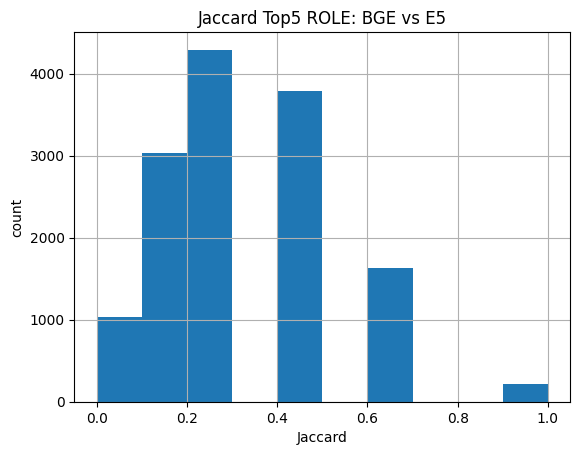

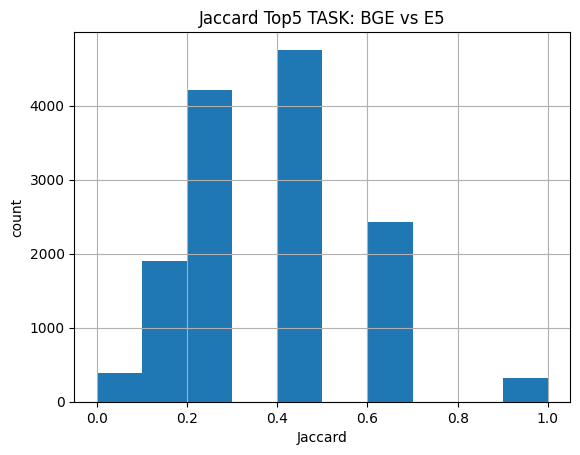


BGE vs E5 | HIGH overlap | job_id=2290735293
ROLE A: ['Fraud Examiners, Investigators and Analysts', 'Financial Examiners', 'Insurance Underwriters', 'Educational, Guidance, and Career Counselors and Advisors', 'Tutors']
ROLE B: ['Fraud Examiners, Investigators and Analysts', 'Insurance Underwriters', 'Tutors', 'Financial Examiners', 'Educational, Guidance, and Career Counselors and Advisors']

BGE vs E5 | LOW overlap | job_id=793311460
ROLE A: ['Couriers and Messengers', 'Driver/Sales Workers', 'Shuttle Drivers and Chauffeurs', 'Light Truck Drivers', 'Bus Drivers, Transit and Intercity']
ROLE B: ['Motorboat Operators', 'Motorcycle Mechanics', 'Tire Repairers and Changers', 'Packers and Packagers, Hand', 'Bicycle Repairers']

BGE vs GTE (3-way set n=13996)
Jaccard ROLE: mean=0.292 p50=0.250 p10=0.111 p90=0.667 min=0.000 max=1.000
Jaccard TASK: mean=0.400 p50=0.429 p10=0.111 p90=0.667 min=0.000 max=1.000
ROLE top1 metrics
  top1 == top1:      0.358
  A top1 in B top5:  0.671
  B top1 i

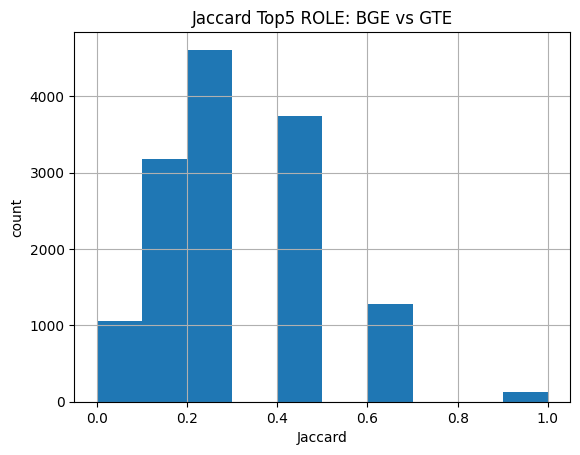

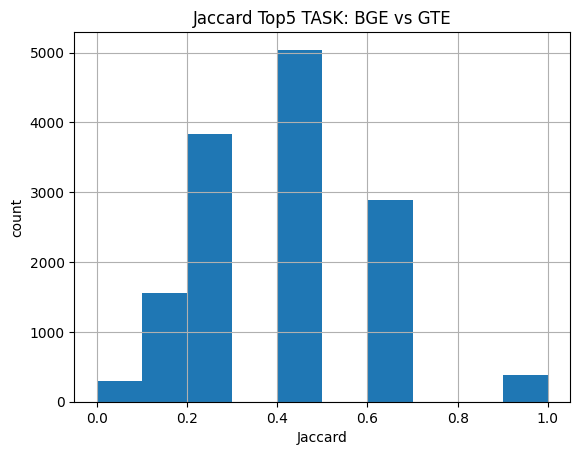


BGE vs GTE | HIGH overlap | job_id=1802300745
ROLE A: ['Exercise Trainers and Group Fitness Instructors', 'Exercise Physiologists', 'Fitness and Wellness Coordinators', 'Recreation and Fitness Studies Teachers, Postsecondary', 'Athletic Trainers']
ROLE B: ['Exercise Trainers and Group Fitness Instructors', 'Fitness and Wellness Coordinators', 'Exercise Physiologists', 'Recreation and Fitness Studies Teachers, Postsecondary', 'Athletic Trainers']

BGE vs GTE | LOW overlap | job_id=2166475651
ROLE A: ['Wholesale and Retail Buyers, Except Farm Products', 'Solar Sales Representatives and Assessors', 'Retail Salespersons', 'Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products', 'Buyers and Purchasing Agents, Farm Products']
ROLE B: ['Advertising Sales Agents', 'Merchandise Displayers and Window Trimmers', 'Demonstrators and Product Promoters', 'New Accounts Clerks', 'Online Merchants']

E5 vs GTE (3-way set n=13996)
Jaccard ROLE: mean=0.288 p50=0.250

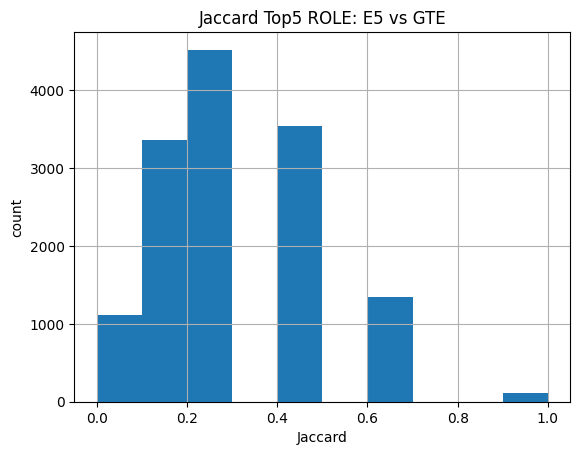

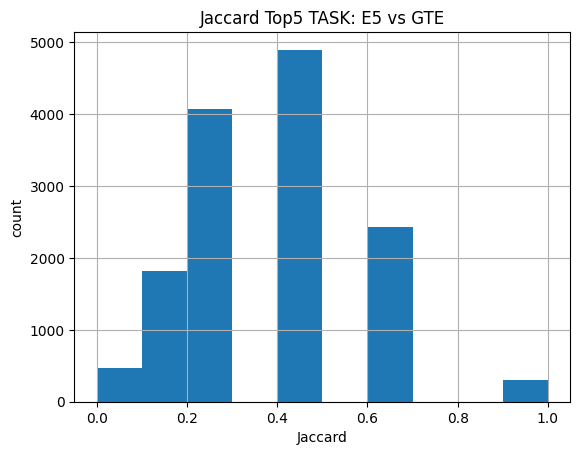


E5 vs GTE | HIGH overlap | job_id=2710110605
ROLE A: ['First-Line Supervisors of Security Workers', 'Security Guards', 'Security Managers', 'Security Management Specialists', 'Locksmiths and Safe Repairers']
ROLE B: ['Security Guards', 'Security Managers', 'Security Management Specialists', 'First-Line Supervisors of Security Workers', 'Locksmiths and Safe Repairers']

E5 vs GTE | LOW overlap | job_id=1648257009
ROLE A: ['Door-to-Door Sales Workers, News and Street Vendors, and Related Workers', 'Tax Preparers', 'Packers and Packagers, Hand', 'Parts Salespersons', 'Telemarketers']
ROLE B: ['Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products', 'Radio Frequency Identification Device Specialists', 'Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products', 'Solar Energy Installation Managers', 'Online Merchants']

MARGIN STATS (BGE vs E5 on 3-way set)
BGE ROLE top1: mean=0.623 p50=0.621 p10=0.555 p90=0.695
BGE ROLE ma

In [28]:
# ============================================================
# VERIFICATION RUNNER (uses your helpers as-is)
# ============================================================
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt



# ---- CONFIG ----
STORE_ROOT = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev")
COS_ROOT = STORE_ROOT / "cosines"

MODEL_DIRS = {
    "bge": COS_ROOT / "bge_large",
    "e5":  COS_ROOT / "e5_large",
    "gte": COS_ROOT / "gte_large",
}

TOPK_EXPECTED = 5
TITLES_NPZ = STORE_ROOT / "embeddings" / "aspectt_vectors.npz"

# ---- RUN ----
titles = load_titles(TITLES_NPZ)

models = {}
for name, root in MODEL_DIRS.items():
    print(f"Loading {name} from {root}")
    models[name] = load_all_parts(root)
    print("  jobs:", len(models[name]["job_ids"]),
          "| role_idx:", models[name]["role_idx"].shape,
          "| task_idx:", models[name]["task_idx"].shape)

all3, idx3 = align_k(models, ["bge", "e5", "gte"])
print("\n" + "="*80)
print("all3:", len(all3))

pairs = [("bge","e5"), ("bge","gte"), ("e5","gte")]

for a, b in pairs:
    A, B = models[a], models[b]
    ia, ib = idx3[a], idx3[b]

    a_role, b_role = A["role_idx"][ia], B["role_idx"][ib]
    a_task, b_task = A["task_idx"][ia], B["task_idx"][ib]

    jac_role = jaccard_topk(a_role, b_role)
    jac_task = jaccard_topk(a_task, b_task)

    print("\n" + "="*80)
    print(f"{a.upper()} vs {b.upper()} (3-way set n={len(all3)})")

    summary(jac_role, "Jaccard ROLE")
    summary(jac_task, "Jaccard TASK")

    top1_metrics(a_role, b_role, "ROLE top1 metrics")
    top1_metrics(a_task, b_task, "TASK top1 metrics")

    plot_hist(jac_role, f"Jaccard Top{TOPK_EXPECTED} ROLE: {a.upper()} vs {b.upper()}")
    plot_hist(jac_task, f"Jaccard Top{TOPK_EXPECTED} TASK: {a.upper()} vs {b.upper()}")

    show_examples(a.upper(), b.upper(), all3, a_role, b_role, titles=titles)

# Optional: margin stats on one pair
a, b = "bge", "e5"
ia, ib = idx3[a], idx3[b]
print("\n" + "="*80)
print("MARGIN STATS (BGE vs E5 on 3-way set)")
margin_stats(models[a]["role_val"][ia], "BGE ROLE")
margin_stats(models[b]["role_val"][ib], "E5  ROLE")
margin_stats(models[a]["task_val"][ia], "BGE TASK")
margin_stats(models[b]["task_val"][ib], "E5  TASK")


E5 seems to disagree more, while bge and gte tend to agree more.

In [29]:
import numpy as np

# ============================================================
# HARD-CASE GATE: run E5 only when BGE vs GTE disagree / low confidence
# Assumes you already have: models, idx3, all3, TOPK_EXPECTED
# ============================================================

# pick the two primary models
A, B = "bge", "gte"
E = "e5"

ia = idx3[A]
ib = idx3[B]
ie = idx3[E]

A_task_idx = models[A]["task_idx"][ia]
B_task_idx = models[B]["task_idx"][ib]

A_task_val = models[A]["task_val"][ia]
B_task_val = models[B]["task_val"][ib]

# confidence = margin(top1-top2)
A_margin = A_task_val[:, 0] - A_task_val[:, 1]
B_margin = B_task_val[:, 0] - B_task_val[:, 1]

# tune these quickly
MARGIN_TH = 0.010          # "low confidence" if below this
DISAGREE_TOP1 = (A_task_idx[:, 0] != B_task_idx[:, 0])
LOW_CONF = (A_margin < MARGIN_TH) | (B_margin < MARGIN_TH)

hard = DISAGREE_TOP1 | LOW_CONF
hard_share = hard.mean()

print(f"Hard-cases share: {hard_share:.3f}  (n={hard.sum()} / {len(hard)})")
print(f"  disagree top1 share: {DISAGREE_TOP1.mean():.3f}")
print(f"  low-margin share:    {LOW_CONF.mean():.3f}  (threshold={MARGIN_TH:.3f})")

# ============================================================
# For hard-cases, use E5 as a tie-breaker / selector
# Strategy: if E5 top1 matches either A or B top1, take that; else keep A (default)
# ============================================================

E_task_idx = models[E]["task_idx"][ie]

A_top1 = A_task_idx[:, 0]
B_top1 = B_task_idx[:, 0]
E_top1 = E_task_idx[:, 0]

# final chosen top1 (start with A)
final_top1 = A_top1.copy()

hard_idx = np.where(hard)[0]
for i in hard_idx:
    if E_top1[i] == B_top1[i]:
        final_top1[i] = B_top1[i]
    elif E_top1[i] == A_top1[i]:
        final_top1[i] = A_top1[i]
    else:
        final_top1[i] = A_top1[i]  # fallback

# how often E5 actually flips the decision away from A on hard cases
flips = np.mean(final_top1[hard] != A_top1[hard]) if hard.any() else 0.0
print(f"E5 flips A decision on hard-cases: {flips:.3f}")

# optional: export the job_ids you need to re-run E5 for (hard cases only)
hard_job_ids = np.array(all3, dtype=object)[hard]
print("Example hard job_ids:", hard_job_ids[:10])


Hard-cases share: 0.742  (n=10390 / 13996)
  disagree top1 share: 0.555
  low-margin share:    0.615  (threshold=0.010)
E5 flips A decision on hard-cases: 0.165
Example hard job_ids: [np.int64(512764618) np.int64(838462377) np.int64(1276410311)
 np.int64(1300283593) np.int64(1300283972) np.int64(1300284160)
 np.int64(1300284175) np.int64(1300284278) np.int64(1300284580)
 np.int64(1300284621)]


In [30]:
# --- recompute hard-gate properly: disagree AND (both margins low) ---
disagree = (A_task_idx[:, 0] != B_task_idx[:, 0])

def hard_share_for(th):
    both_low = (A_margin < th) & (B_margin < th)
    hard = disagree & both_low
    return hard, both_low

# single threshold report
TH = 0.005
hard, both_low = hard_share_for(TH)

print(f"TH={TH:.3f}")
print(f"  disagree share:   {disagree.mean():.3f} (n={disagree.sum()} / {len(disagree)})")
print(f"  both-low share:   {both_low.mean():.3f} (n={both_low.sum()} / {len(both_low)})")
print(f"  HARD share:       {hard.mean():.3f} (n={hard.sum()} / {len(hard)})")

# sweep thresholds to hit ~10-25% hard cases
print("\nThreshold sweep (aim hard ~0.10–0.25):")
for th in [0.006, 0.005, 0.004, 0.003, 0.002, 0.0015, 0.001, 0.0007, 0.0005]:
    hard, _ = hard_share_for(th)
    print(f"  th={th:0.4f}  hard_share={hard.mean():.3f}  n={hard.sum()}")

# optional: list a few hard ids
hard_job_ids = np.array(all3, dtype=object)[hard]
print("\nExample hard job_ids:", hard_job_ids[:10])


TH=0.005
  disagree share:   0.555 (n=7771 / 13996)
  both-low share:   0.063 (n=882 / 13996)
  HARD share:       0.051 (n=719 / 13996)

Threshold sweep (aim hard ~0.10–0.25):
  th=0.0060  hard_share=0.070  n=980
  th=0.0050  hard_share=0.051  n=719
  th=0.0040  hard_share=0.036  n=506
  th=0.0030  hard_share=0.023  n=317
  th=0.0020  hard_share=0.010  n=145
  th=0.0015  hard_share=0.006  n=83
  th=0.0010  hard_share=0.004  n=54
  th=0.0007  hard_share=0.002  n=23
  th=0.0005  hard_share=0.002  n=23

Example hard job_ids: [np.int64(2794828830) np.int64(2832961132) np.int64(2847301937)
 np.int64(2888782881) np.int64(2917419002) np.int64(2939924292)
 np.int64(2954005429) np.int64(2955868365) np.int64(2996196930)
 np.int64(3230917231)]


Ideas for further validation:

Build dev slice

Add 2 strata you missed:

domain drift risk (retail selling software, logistics containers, etc)

hard cases (BGE vs GTE disagree + both low margin)

So you can measure what matters, not random ads.

3) create final dataset

In [1]:
import numpy as np
from pathlib import Path
from collections import defaultdict


# -----------------------------------------------------------------------------
# Merge (intersection on job_ids)
# -----------------------------------------------------------------------------
def merge_job_data(cos_path, llama_path, out_path):
    """Merge COS + LLAMA on job_ids (keeps intersection)."""
    cos_path = Path(cos_path)
    llama_path = Path(llama_path)
    out_path = Path(out_path)

    a = np.load(cos_path, allow_pickle=True)
    b = np.load(llama_path, allow_pickle=True)

    if "job_ids" not in a.files or "job_ids" not in b.files:
        raise KeyError("Both inputs must contain 'job_ids'")

    a_ids = np.array([str(x) for x in a["job_ids"]], dtype=object)
    b_ids = np.array([str(x) for x in b["job_ids"]], dtype=object)

    b_idx_map = {jid: i for i, jid in enumerate(b_ids)}

    mask = np.array([jid in b_idx_map for jid in a_ids], dtype=bool)
    idx_a = np.where(mask)[0].astype(np.int64)
    idx_b = np.array([b_idx_map[jid] for jid in a_ids[mask]], dtype=np.int64)

    if len(idx_a) == 0:
        print(f"No matches for {out_path.name}. Skipping.")
        return 0

    merged = {}
    nA = len(a_ids)
    nB = len(b_ids)

    # COS side: slice only row-wise arrays
    for k in a.files:
        v = a[k]
        if hasattr(v, "shape") and getattr(v, "ndim", 0) >= 1 and v.shape[0] == nA:
            merged[k] = v[idx_a]
        else:
            merged[k] = v

    # LLAMA side: slice only row-wise arrays; exclude join key
    for k in b.files:
        if k == "job_ids":
            continue
        v = b[k]
        if hasattr(v, "shape") and getattr(v, "ndim", 0) >= 1 and v.shape[0] == nB:
            merged[k] = v[idx_b]
        else:
            merged[k] = v

    out_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(out_path, **merged)
    print(f"Saved {len(idx_a):,} rows to {out_path}")
    return len(idx_a)


# -----------------------------------------------------------------------------
# Build COS month file (and optionally FILTER to a given set of job_ids)
# -----------------------------------------------------------------------------
def build_month(
    model_dir,
    aspectt_npz,
    month,
    out_dir,
    alpha=0.5,
    topn=10,
    filter_job_ids=None,          # <- NEW
    require_full_match=True,      # <- NEW (fail fast if not all LLAMA ids found)
):
    """
    Builds {out_dir}/{month}.npz from shards under model_dir.

    If filter_job_ids is provided:
      - filters all row-wise arrays to those ids (intersection)
      - optionally requires full match (default True): raises if missing any
    """
    model_dir = Path(model_dir)
    out_dir = Path(out_dir)

    parts = sorted(model_dir.glob(f"{month}_shard*/part_*.npz"))
    assert parts, f"No shards found for {month} in {model_dir}"

    d0 = np.load(parts[0], allow_pickle=True)
    M = {k: [] for k in d0.files}

    for p in parts:
        d = np.load(p, allow_pickle=True)
        for k in M:
            M[k].append(d[k])

    # concat rows, keep first scalar
    for k in list(M):
        arr0 = np.asarray(M[k][0])
        M[k] = arr0 if arr0.ndim == 0 else np.concatenate(M[k], axis=0)

    # --- optional filter to LLAMA ids (forces alignment across models) ---
    if filter_job_ids is not None:
        want = np.array([str(x) for x in filter_job_ids], dtype=object)
        want_set = set(want.tolist())

        have = np.array([str(x) for x in M["job_ids"]], dtype=object)
        keep = np.array([jid in want_set for jid in have], dtype=bool)

        # fast fail if your COS month doesn't contain LLAMA ids
        if require_full_match:
            have_set = set(have.tolist())
            missing = want_set - have_set
            if missing:
                raise ValueError(
                    f"{month}: missing {len(missing)} of {len(want_set)} filter_job_ids in {model_dir}"
                )

        # slice all row-wise arrays in M
        for k in list(M):
            v = M[k]
            if hasattr(v, "ndim") and v.ndim >= 1 and v.shape[0] == len(have):
                M[k] = v[keep]

    # ---- map indices -> titles ----
    titles = np.load(aspectt_npz, allow_pickle=True)["titles"]

    rt = titles[M["role_topk_idx"]]
    rv = M["role_topk_val"].astype(float)
    tt = titles[M["task_topk_idx"]]
    tv = M["task_topk_val"].astype(float)

    n = rt.shape[0]
    candidates = np.empty(n, dtype=object)
    candidates_dict = np.empty(n, dtype=object)

    for i in range(n):
        agg = defaultdict(float)

        for t, w in zip(rt[i], rv[i]):
            agg[t] += alpha * float(w)

        for t, w in zip(tt[i], tv[i]):
            agg[t] += (1 - alpha) * float(w)

        candidates_dict[i] = dict(agg)
        candidates[i] = [t for t, _ in sorted(agg.items(), key=lambda x: -x[1])[:topn]]

    out_dir.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_dir / f"{month}.npz",
        **{k: v for k, v in M.items() if k not in ["chunk_start", "chunk_end"]},
        candidates=candidates,
        candidates_dict=candidates_dict,
        alpha=np.float32(alpha),
    )


# -----------------------------------------------------------------------------
# Driver: build (aligned to LLAMA job_ids) then merge for all months/models
# -----------------------------------------------------------------------------
def build_then_merge_all_months(
    months,
    base_dir,
    model_name,
    model_dir,
    aspectt_npz,
    llama_subdir="llama_summary_1000s",
    alpha=0.4,
    topn=10,
):
    """
    Guarantees full matches by building COS filtered to LLAMA job_ids.
    Result: merged outputs should be ~1000 rows per month for every model (if COS has those ids).
    """
    base = Path(base_dir)

    temp_dir = base / f"cosines/cosine_merged/{model_name}/temp"
    final_dir = base / f"cosines/cosine_merged/{model_name}"
    llama_dir = base / llama_subdir

    temp_dir.mkdir(parents=True, exist_ok=True)
    final_dir.mkdir(parents=True, exist_ok=True)

    for month in months:
        print(f"\n== {model_name} | {month} ==")

        cos_p = temp_dir / f"{month}.npz"
        llama_p = llama_dir / f"{month}.npz"
        out_p = final_dir / f"{month}.npz"

        if not llama_p.exists():
            print(f"[SKIP] Missing LLAMA: {llama_p}")
            continue

        # load LLAMA ids first so COS is built on the same sample
        llama = np.load(llama_p, allow_pickle=True)
        llama_ids = llama["job_ids"]

        # build COS (aligned to LLAMA ids)
        print(f"[BUILD] {cos_p}")
        build_month(
            model_dir=model_dir,
            aspectt_npz=aspectt_npz,
            month=month,
            out_dir=temp_dir,
            alpha=alpha,
            topn=topn,
            filter_job_ids=llama_ids,      # <- THE FIX
            require_full_match=False,      # set True if you want it to hard fail
        )

        # merge (now should match fully or near-fully)
        merge_job_data(cos_p, llama_p, out_p)


# -----------------------------------------------------------------------------
# RUN ALL MODELS
# -----------------------------------------------------------------------------
MONTHS = [f"adzuna_month{m:02d}" for m in range(1, 15)]

BASE_DIR = (
    "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/"
    "AISI_demo/stage_2_embeddings_and_cosines/dev"
)

ASPECTT_NPZ = (
    "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/"
    "AISI_demo/stage_2_embeddings_and_cosines/dev/embeddings/aspectt_vectors.npz"
)

MODELS = {
    "bge_large": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/bge_large",
    "e5_large":  "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/e5_large",
    "gte_large": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/gte_large",
}

for model_name, model_dir in MODELS.items():
    build_then_merge_all_months(
        months=MONTHS,
        base_dir=BASE_DIR,
        model_name=model_name,
        model_dir=model_dir,
        aspectt_npz=ASPECTT_NPZ,
        alpha=0.4,
        topn=10,
    )



== bge_large | adzuna_month01 ==
[BUILD] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/temp/adzuna_month01.npz
Saved 1,000 rows to /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/adzuna_month01.npz

== bge_large | adzuna_month02 ==
[BUILD] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/temp/adzuna_month02.npz
Saved 1,000 rows to /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/adzuna_month02.npz

== bge_large | adzuna_month03 ==
[BUILD] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/temp/adzuna_month03.npz
Saved 1,0

In [2]:
import numpy as np
from pathlib import Path

BASE = Path(
    "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/"
    "AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged"
)
MODELS = ["bge_large", "e5_large", "gte_large"]
MONTH = "adzuna_month06.npz"

def load_model(model):
    path = BASE / model / MONTH
    d = np.load(path, allow_pickle=True)
    ids = np.array([str(x) for x in d["job_ids"]], dtype=object)
    idx = {jid: i for i, jid in enumerate(ids)}
    return d, idx, path

# choose an anchor job_id: take first from e5 (you can change this)
d_anchor, idx_anchor, _ = load_model("e5_large")
target_jid = str(d_anchor["job_ids"][-143])
print("TARGET job_id:", target_jid)

for model in MODELS:
    d, idx, path = load_model(model)
    print(f"\n===== {model} =====")
    if target_jid not in idx:
        print("MISSING job_id in this model file:", path)
        continue
    i = idx[target_jid]
    for k in d.files:
        v = d[k]
        if hasattr(v, "ndim") and v.ndim >= 1 and v.shape[0] == len(d["job_ids"]):
            print(f"{k}: {v[i]}")
        else:
            print(f"{k}: {v}")


TARGET job_id: 3149912361

===== bge_large =====
job_ids: 3149912361
role_topk_idx: [86 87 47 58 88]
role_topk_val: [0.6313 0.6025 0.5957 0.593  0.5825]
task_topk_idx: [88 58 47 61 11]
task_topk_val: [0.718  0.7163 0.684  0.6636 0.661 ]
month: ['adzuna_month06_shard00' 'adzuna_month06_shard01']
candidates: ['Compliance Officers', 'Financial Examiners', 'Compliance Managers', 'Regulatory Affairs Specialists', 'Financial Managers', 'Personal Financial Advisors', 'Insurance Underwriters']
candidates_dict: {'Personal Financial Advisors': 0.2525390625, 'Insurance Underwriters': 0.241015625, 'Compliance Managers': 0.64873046875, 'Compliance Officers': 0.66689453125, 'Financial Examiners': 0.663671875, 'Regulatory Affairs Specialists': 0.39814453125, 'Financial Managers': 0.3966796875}
alpha: 0.4000000059604645
role_text: [Accounting & Finance] Compliance Advisor Insurance
taskskill_text: [Accounting & Finance] Provide advice and support to senior management and staff on compliance matters As

In [3]:
import numpy as np
from pathlib import Path
BASE = Path(
    "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/"
    "AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged"
)
MODELS = ["bge_large", "e5_large", "gte_large"]
MONTH = "adzuna_month06.npz"
ANCHOR = "e5_large"

def load_ids(model):
    path = BASE / model / MONTH
    d = np.load(path, allow_pickle=True)
    ids = np.array([str(x) for x in d["job_ids"]], dtype=object)

    # basic hygiene
    if np.any(ids == "None") or np.any(ids == ""):
        bad = np.where((ids == "None") | (ids == ""))[0][:10]
        raise ValueError(f"{model}: empty/None job_ids at rows {bad.tolist()} in {path}")

    # duplicates
    uniq, counts = np.unique(ids, return_counts=True)
    dup = uniq[counts > 1]
    if dup.size:
        raise ValueError(f"{model}: duplicate job_ids (showing up to 10): {dup[:10].tolist()}")

    return path, d, ids

# load anchor first
anchor_path, anchor_d, anchor_ids = load_ids(ANCHOR)
anchor_set = set(anchor_ids)
anchor_n = len(anchor_ids)

print(f"ANCHOR={ANCHOR} n={anchor_n} file={anchor_path}")

# compare all models vs anchor
for model in MODELS:
    path, d, ids = load_ids(model)
    print(f"\n=== {model} ===")
    print(f"n={len(ids)} file={path}")

    # 1) same length
    if len(ids) != anchor_n:
        print(f"FAIL: length mismatch vs anchor ({len(ids)} vs {anchor_n})")

    # 2) same set (missing/extras)
    s = set(ids)
    missing = list(anchor_set - s)
    extra = list(s - anchor_set)
    if missing:
        print(f"FAIL: missing {len(missing)} ids (first 10): {missing[:10]}")
    if extra:
        print(f"FAIL: extra {len(extra)} ids (first 10): {extra[:10]}")
    if not missing and not extra:
        print("OK: same ID set as anchor")

    # 3) same order (critical for row-wise comparisons)
    if len(ids) == anchor_n and not missing and not extra:
        order_ok = np.array_equal(ids, anchor_ids)
        print("OK: same order as anchor" if order_ok else "FAIL: same set but DIFFERENT order")

        # if order differs, show a few first mismatches
        if not order_ok:
            mism = np.where(ids != anchor_ids)[0][:10]
            print("First mismatched rows:", mism.tolist())
            for i in mism:
                print(f"  row {i}: anchor={anchor_ids[i]}  {model}={ids[i]}")


ANCHOR=e5_large n=1000 file=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/e5_large/adzuna_month06.npz

=== bge_large ===
n=1000 file=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/bge_large/adzuna_month06.npz
OK: same ID set as anchor
OK: same order as anchor

=== e5_large ===
n=1000 file=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/e5_large/adzuna_month06.npz
OK: same ID set as anchor
OK: same order as anchor

=== gte_large ===
n=1000 file=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_2_embeddings_and_cosines/dev/cosines/cosine_merged/gte_large/adzuna_month06.npz
OK: same ID set as anchor
OK: same order as anchor
